# 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



# 2. Load test data

In [2]:
x_test_processed = pd.read_csv("../data/processed/x_test_processed.csv").values
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze().values

# 3. Load saved model

In [3]:
model = joblib.load("../models/logistic_regression_model.pkl")

# 4. Predict

In [4]:
y_pred = model.predict(x_test_processed)

# 5. Compute metrics


In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8524590163934426
F1 Score: 0.8363636363636363
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        33
           1       0.85      0.82      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

[[29  4]
 [ 5 23]]


# 6. Plot confusion matrix

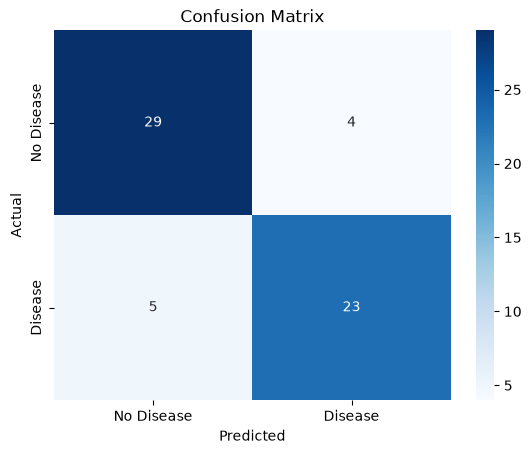

In [6]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### conclusion

In [7]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"The Logistic Regression model achieved an accuracy of {accuracy_score(y_test, y_pred):.1%} and an F1 score of {f1_score(y_test, y_pred):.1%}.")
print(f"The confusion matrix shows {tn} true negatives, {tp} true positives, and {fp + fn} incorrect predictions.")
print("Labels: 1 = disease present, 0 = no disease.")

The Logistic Regression model achieved an accuracy of 85.2% and an F1 score of 83.6%.
The confusion matrix shows 29 true negatives, 23 true positives, and 9 incorrect predictions.
Labels: 1 = disease present, 0 = no disease.
